In [1]:
import numpy as np
from mpi4py import MPI
from dolfinx import mesh, geometry, fem
import ufl
import gmsh
from dolfinx.io import gmsh as gmshio
from dolfinx.fem.petsc import NonlinearProblem
from petsc4py import PETSc
import basix.ufl
import matplotlib.pyplot as plt
import pyvista as pv
import dolfinx.plot
import pandas as pd
from dolfinx import io

In [ ]:
def project_to_P1(domain, u):
    element_P1 = basix.ufl.element("Lagrange", domain.topology.cell_name(), 1, shape=(3,))
    V1 = fem.functionspace(domain, element_P1)
    u_P1 = fem.Function(V1)
    u_P1.interpolate(u)
    return u_P1

def project_Piola_P1(domain, P_expr):
    element = basix.ufl.element("Lagrange", domain.topology.cell_name(), 1, shape=(3, 3))
    V = fem.functionspace(domain, element)
    expr = fem.Expression(P_expr, V.element.interpolation_points)
    P_fun = fem.Function(V)
    P_fun.interpolate(expr)
    return P_fun


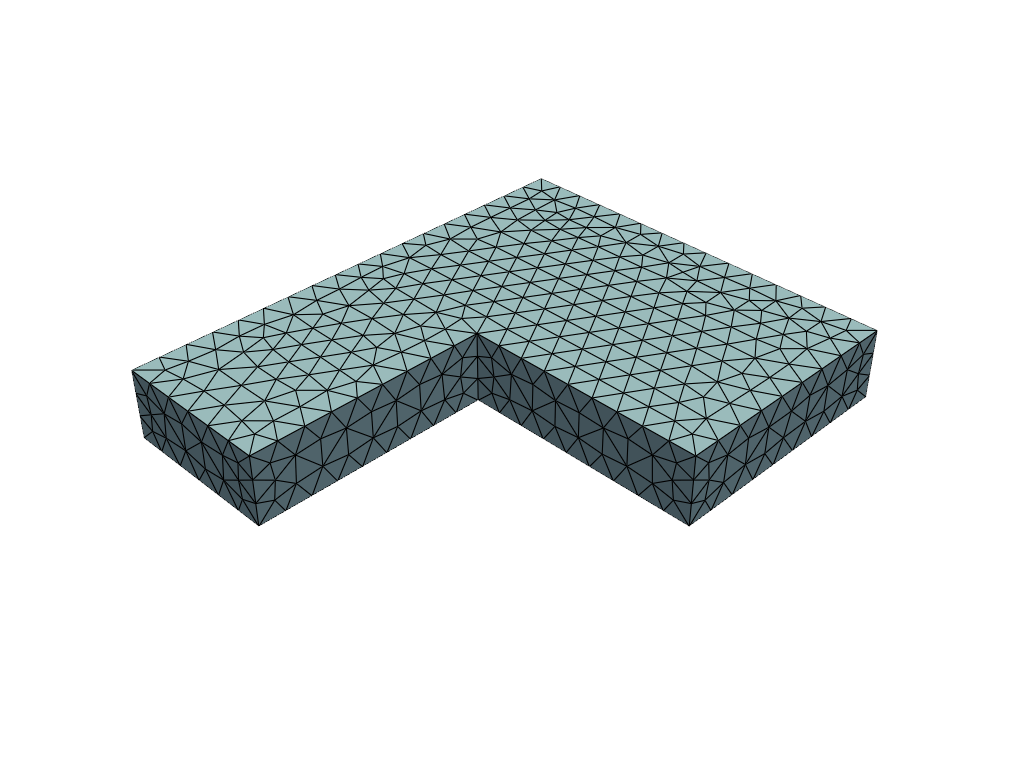

(<dolfinx.mesh.Mesh at 0x7e27ef563f80>,
 <dolfinx.mesh.MeshTags at 0x7e27f26e77a0>)

In [ ]:
def create_geometry_biaxiale(h):
    gmsh.initialize()                                               
    gmsh.option.setNumber("General.Verbosity", 0)

    a=17.5
    b=17
    c=17
    d=23/2

    horizontalLegLength = a+b
    verticalLegLength = c+d

    verticalLegThickness = a
    horizontalLegThickness = d

    depth = 5 

    p1 = gmsh.model.geo.addPoint(0,   0,   0, h)
    p2 = gmsh.model.geo.addPoint(horizontalLegLength,   0,   0, h)
    p3 = gmsh.model.geo.addPoint(horizontalLegLength,  horizontalLegThickness,   0, h)
    p4 = gmsh.model.geo.addPoint(verticalLegThickness, horizontalLegThickness,   0, h)
    p5 = gmsh.model.geo.addPoint(verticalLegThickness,  verticalLegLength,   0, h)
    p6 = gmsh.model.geo.addPoint(0,   verticalLegLength,   0, h)

    l1 = gmsh.model.geo.addLine(p1, p2)
    l2 = gmsh.model.geo.addLine(p2, p3)
    l3 = gmsh.model.geo.addLine(p3, p4)
    l4 = gmsh.model.geo.addLine(p4, p5)
    l5 = gmsh.model.geo.addLine(p5, p6)
    l6 = gmsh.model.geo.addLine(p6, p1)

    loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4, l5, l6])
    surf = gmsh.model.geo.addPlaneSurface([loop])

    gmsh.model.geo.synchronize()

    # Extrude

    out = gmsh.model.geo.extrude([(2, surf)], 0, 0, depth)

    gmsh.model.geo.synchronize()

    # Identify entities

    left_faces = []
    bottom_faces = []
    right_faces = []
    top_faces = []
    front_faces = []

    eps = 1e-8

    for dim, tag in gmsh.model.getEntities(2):

        xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(dim, tag)

        if abs(xmin) < eps and abs(xmax) < eps:
            left_faces.append(tag)

        if abs(ymin) < eps and abs(ymax) < eps:
            bottom_faces.append(tag)

        if abs(xmin - horizontalLegLength) < eps and abs(xmax - horizontalLegLength) < eps:
            right_faces.append(tag)

        if abs(ymin - verticalLegLength) < eps and abs(ymax - verticalLegLength) < eps:
            top_faces.append(tag)

        if abs(zmin) < eps and abs(zmax) < eps:
            front_faces.append(tag)

    volumes = [tag for _, tag in gmsh.model.getEntities(3)]

    # Physical groups

    gmsh.model.addPhysicalGroup(2, left_faces, 1)
    gmsh.model.setPhysicalName(2, 1, "left")

    gmsh.model.addPhysicalGroup(2, bottom_faces, 2)
    gmsh.model.setPhysicalName(2, 2, "bottom")

    gmsh.model.addPhysicalGroup(3, volumes, 10)
    gmsh.model.setPhysicalName(3, 10, "volume")

    gmsh.model.addPhysicalGroup(2, right_faces, 3)
    gmsh.model.setPhysicalName(2, 3, "right")

    gmsh.model.addPhysicalGroup(2, top_faces, 4)
    gmsh.model.setPhysicalName(2, 4, "top")

    gmsh.model.addPhysicalGroup(2, front_faces, 5)
    gmsh.model.setPhysicalName(2, 5, "front")

    # Mesh

    gmsh.model.mesh.generate(3)
    data = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0, gdim=3)

    msh = data.mesh
    facet_tags = data.facet_tags
    cell_tags = data.cell_tags

    msh.topology.create_connectivity(2, 3)
    msh.topology.create_connectivity(1, 2)
    msh.topology.create_connectivity(1, 3)

    topology, cell_types, geometry = dolfinx.plot.vtk_mesh(msh)
    pv.set_jupyter_backend("static")
    grid = pv.UnstructuredGrid(topology, cell_types, geometry)
    plotter = pv.Plotter()
    plotter.add_mesh(grid, show_edges=True)
    plotter.show()

    gmsh.finalize()

    return msh, facet_tags, cell_tags

create_geometry_biaxiale(2)

In [ ]:
def evaluate_Moonley_Riv_Piola(msh: mesh.Mesh, facet_tags: mesh.MeshTags, cell_tags: mesh.MeshTags, k: int) -> float:
    domain = msh

    element_u = basix.ufl.element("Lagrange", domain.topology.cell_name(), k, shape=(3,))
    element_p = basix.ufl.element("Lagrange", domain.topology.cell_name(), k-1)
    mixed_el = basix.ufl.mixed_element([element_u, element_p])
    V = fem.functionspace(domain, mixed_el)

    V_u = V.sub(0)
    V_u0, _ = V_u.collapse()

    V_u_x = V_u.sub(0)
    V_u_x0, _ = V_u_x.collapse()
    boundary_1 = facet_tags.find(1)
    dofs_1 = fem.locate_dofs_topological((V_u_x, V_u_x0),domain.topology.dim - 1,boundary_1)
    u_D_1 = fem.Function(V_u_x0)
    u_D_1.x.array[:] = 0.0
    bc_1 = fem.dirichletbc(u_D_1,dofs_1,V_u_x)

    V_u_y = V_u.sub(1)
    V_u_y0, _ = V_u_y.collapse()
    boundary_2 = facet_tags.find(2)
    dofs_2 = fem.locate_dofs_topological((V_u_y, V_u_y0),domain.topology.dim - 1,boundary_2)
    u_D_2 = fem.Function(V_u_y0)
    u_D_2.x.array[:] = 0.0
    bc_2 = fem.dirichletbc(u_D_2,dofs_2,V_u_y)

    V_u_z = V_u.sub(2)
    V_u_z0, _ = V_u_z.collapse()
    boundary_3 = facet_tags.find(5)
    dofs_3 = fem.locate_dofs_topological((V_u_z, V_u_z0),domain.topology.dim - 1,boundary_3)
    u_D_3 = fem.Function(V_u_z0)
    u_D_3.x.array[:] = 0.0
    bc_3 = fem.dirichletbc(u_D_3,dofs_3,V_u_z)

    bcs = [bc_1, bc_2, bc_3]

    def invariants(F):
        C = F.T * F
        I1 = ufl.tr(C)
        I2 = 0.5 * (ufl.tr(C)**2 - ufl.tr(C*C))
        return C,I1,I2

    def value_Piso(F, C10, C01, C02):
        C, I1, I2 = invariants(F)
        dI1dF = 2*F
        dI2dF = 2*(I1*F - F*C)
        dW_dI2 = C01 + 2*C02*(I2 - 3)
        P_iso = C10*dI1dF + dW_dI2*dI2dF
        return P_iso

    def F_def(u):
        return ufl.Identity(3) + ufl.grad(u)

    C01 = 17.4
    C10 = -11.11
    C02 = 3.134
    kappa = 10000

    up = fem.Function(V)
    vq = ufl.TestFunction(V)
    u, p = ufl.split(up)
    v, q = ufl.split(vq)
    
    F = F_def(u)
    J = ufl.det(F)

    P_iso = value_Piso(F, C10, C01, C02)
    ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)
    sigma_x = fem.Constant(domain, PETSc.ScalarType((2, 0.0, 0.0)))
    sigma_y = fem.Constant(domain, PETSc.ScalarType((0.0, 4, 0.0)))

    P = P_iso + p*J*ufl.inv(F).T + kappa*(J - 1)*J*ufl.inv(F).T
    R_total = ufl.inner(P, ufl.grad(v))*ufl.dx + q*(J - 1)*ufl.dx- ufl.inner(sigma_y, v) * ds(4)- ufl.inner(sigma_x, v) * ds(3)

    dup = ufl.TrialFunction(V)
    J_total = ufl.derivative(R_total, up, dup)

    linear_solver = "mumps"
    ChildProcessError
    petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_stol": 1e-8,
    "snes_atol": 1e-6,
    "snes_rtol": 1e-6,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "snes_max_it": 1000,
    "pc_factor_mat_solver_type": linear_solver,
    "pc_factor_mat_solver_type": "mumps",
    "mat_mumps_icntl_14": 200,  
    "mat_mumps_icntl_24": 1,   
    "mat_mumps_icntl_7": 0,     
    "mat_mumps_icntl_6": 1,     
    "mat_mumps_icntl_8": 7,    
    "mat_mumps_icntl_9": 1,    
    "snes_monitor": None,}

    problem = NonlinearProblem(
        R_total, up,
        bcs=bcs,
        J=J_total,  
        petsc_options_prefix="nonlinear_",
        petsc_options=petsc_options)


    with io.XDMFFile(domain.comm, "hyperelasticity_biaxiale.xdmf", "w") as file:
        file.write_mesh(domain)

        u_sol = problem.solve()

        u_fun = u_sol.sub(0).collapse()
        p_fun = u_sol.sub(1).collapse()

        u_P1 = project_to_P1(domain, u_fun)
        u_P1.name = "u_1"
        file.write_function(u_P1)

        F_sol = F_def(u_fun)
        J_sol = ufl.det(F_sol)
        P_iso_sol = value_Piso(F_sol, C10, C01, C02)
        
        P_vol_sol = kappa * (J_sol - 1) * J_sol * ufl.inv(F_sol).T
        P_expr = P_iso_sol + p_fun * J_sol * ufl.inv(F_sol).T + P_vol_sol

        V_P_post = fem.functionspace(domain,basix.ufl.element("P",domain.basix_cell(),1,shape=(3, 3)))

        P_post = fem.Expression(P_expr,V_P_post.element.interpolation_points)

        P_out = fem.Function(V_P_post)
        P_out.name = "P"
        P_out.interpolate(P_post)
        P_out.name = "P_out"
        #file.write_function(P_out)

    return 

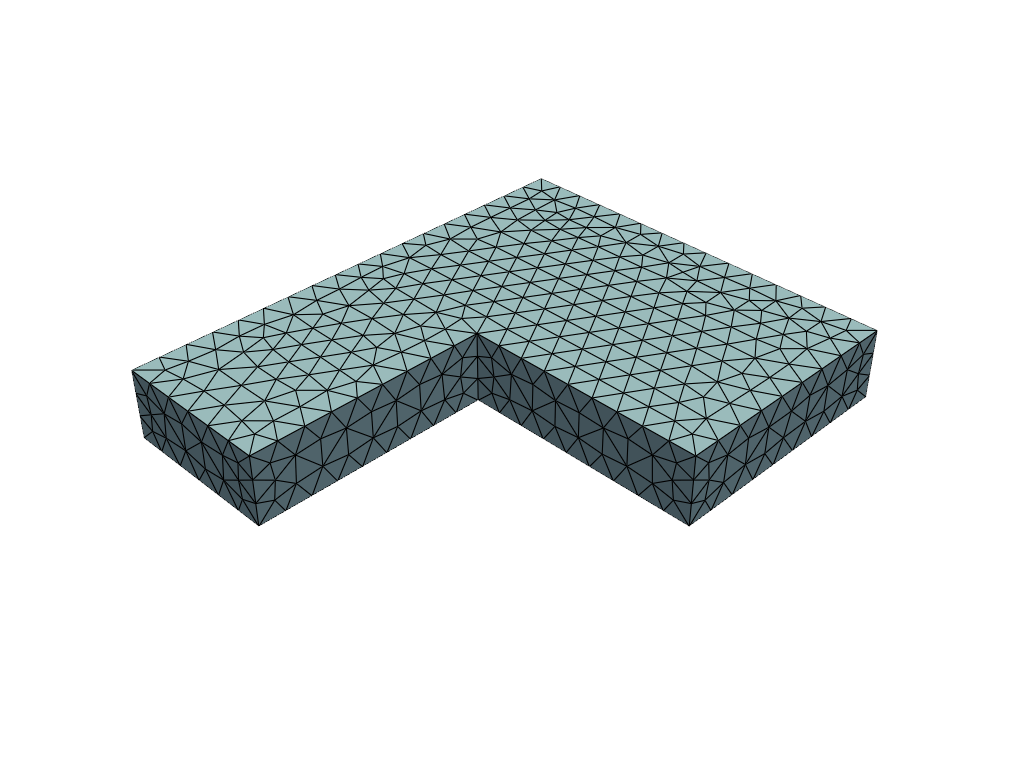

  0 SNES Function norm 1.455478133829e+03
  1 SNES Function norm 1.272175664186e+03
  2 SNES Function norm 1.242882051990e+03
  3 SNES Function norm 1.190998722302e+03
  4 SNES Function norm 1.177330245315e+03
  5 SNES Function norm 1.140073186539e+03
  6 SNES Function norm 1.136888979892e+03
  7 SNES Function norm 1.103138288205e+03
  8 SNES Function norm 1.065897207404e+03
  9 SNES Function norm 1.055904631640e+03
 10 SNES Function norm 1.032708901841e+03
 11 SNES Function norm 9.634442267081e+02
 12 SNES Function norm 9.514005303658e+02
 13 SNES Function norm 9.378061299327e+02
 14 SNES Function norm 8.701128389181e+02
 15 SNES Function norm 8.464179817171e+02
 16 SNES Function norm 7.877929155227e+02
 17 SNES Function norm 7.537712328352e+02
 18 SNES Function norm 6.973321010452e+02
 19 SNES Function norm 6.203525386707e+02
 20 SNES Function norm 5.644006060887e+02
 21 SNES Function norm 5.111106403861e+02
 22 SNES Function norm 4.870506305151e+02
 23 SNES Function norm 4.726272560

In [5]:
import os

for filename in ["hyperelasticity_biaxiale.xdmf","hyperelasticity_biaxiale.h5"]:
    if os.path.exists(filename):
        os.remove(filename)

msh, facet_tags, cell_tags = create_geometry_biaxiale(2)
evaluate_Moonley_Riv_Piola(msh, facet_tags, cell_tags,2)